<a href="https://colab.research.google.com/github/umer0345/Machine-Learning-Based-Cloud-Offloading-Decision-Model/blob/main/AIproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AI & ML Project:** *Task offloading using RandomForest Classifier*
---



# **Important Library Imports**

In [ ]:
# Standard library imports
import random # Used for generating random choices in the simulation

# Related third party imports
import numpy as np # For numerical operations, especially in data simulation
import pandas as pd # For data manipulation and analysis (DataFrames)
import matplotlib.pyplot as plt # For creating static, interactive, and animated visualizations
import seaborn as sns # Built on matplotlib, provides a high-level interface for drawing attractive statistical graphics

# specific IPython imports
from IPython import get_ipython # Used for IPython specific functionalities
from IPython.display import display # To display dataframes and other objects nicely in Colab/Jupyter

# Machine learning libraries
from sklearn.model_selection import train_test_split # For splitting data into training and testing sets
from sklearn.ensemble import RandomForestClassifier # The machine learning model used for offloading decision
from sklearn.metrics import classification_report, confusion_matrix # For evaluating the model's performance
from sklearn.preprocessing import StandardScaler # Although imported, not used in the current code

# **Simulate Telemetry Data**

In [ ]:
def decide_offload_target(cpu, battery, latency, size, complexity):
    # Try to run locally
    if cpu < 70 and battery > 30 and latency < 200:
        return 0  # Local

    # Server 1 specs
    if cpu < 90 and size <= 4000 and complexity in ['low', 'medium']:
        return 1  # Server 1

    # Server 2 specs
    if cpu < 95 and size <= 8000:
        return 2  # Server 2

    # Else use cloud
    return 3  # Cloud


In [ ]:
# Simulate multi-user telemetry data
def simulate_multi_user_data(n_users=10, tasks_per_user=100):
    np.random.seed(42)
    data = []

    task_complexity_levels = ['low', 'medium', 'high']

    for user_id in range(1, n_users + 1):
        for t in range(tasks_per_user):
            cpu = np.random.uniform(5, 95)                         # CPU usage %
            battery = np.random.uniform(10, 100)                   # Battery level %
            network_latency = np.random.uniform(20, 300)           # ms
            bandwidth = np.random.uniform(500, 100_000)            # kbps
            data_size = np.random.uniform(100, 10_000)             # KB
            task_complexity = random.choice(task_complexity_levels)

            offload_target = decide_offload_target(cpu, battery, network_latency, data_size, task_complexity)

            entry = {
                'user_id': user_id,
                'CPU_Usage(%)': cpu,
                'Battery_Level(%)': battery,
                'Network_Latency(ms)': network_latency,
                'Bandwidth_Availability(kbps)': bandwidth,
                'Data_Size(KB)': data_size,
                'Task_Complexity': task_complexity,
                'Offload_Target': offload_target,
            }
            data.append(entry)


    return pd.DataFrame(data)


In [ ]:
df = simulate_multi_user_data(n_users=5, tasks_per_user=200)
display(df)

,user_id,CPU_Usage(%),Battery_Level(%),Network_Latency(ms),Bandwidth_Availability(kbps),Data_Size(KB),Task_Complexity,Offload_Target
0,1,38.708611,95.564288,224.958304,60066.519178,1644.584540,medium,1
1,1,19.039507,15.227525,262.529321,60310.943668,7109.918520,medium,2
2,1,6.852604,97.291887,253.083939,21627.741512,1900.067175,medium,1
3,1,21.506406,37.381802,166.931801,43478.529355,2983.168488,low,0
4,1,60.066761,22.554447,101.800502,36953.003408,4615.092844,high,2
...,...,...,...,...,...,...,...,...
995,5,45.205382,21.110488,77.674410,593.869819,488.724011,medium,1
996,5,92.955544,31.811833,205.726999,83990.420031,5551.538546,medium,2
997,5,18.783005,75.530479,188.070395,73259.433640,7720.491566,high,0
998,5,92.786933,61.620695,115.659512,65022.223412,777.563022,medium,2


# **Visualize the Data**

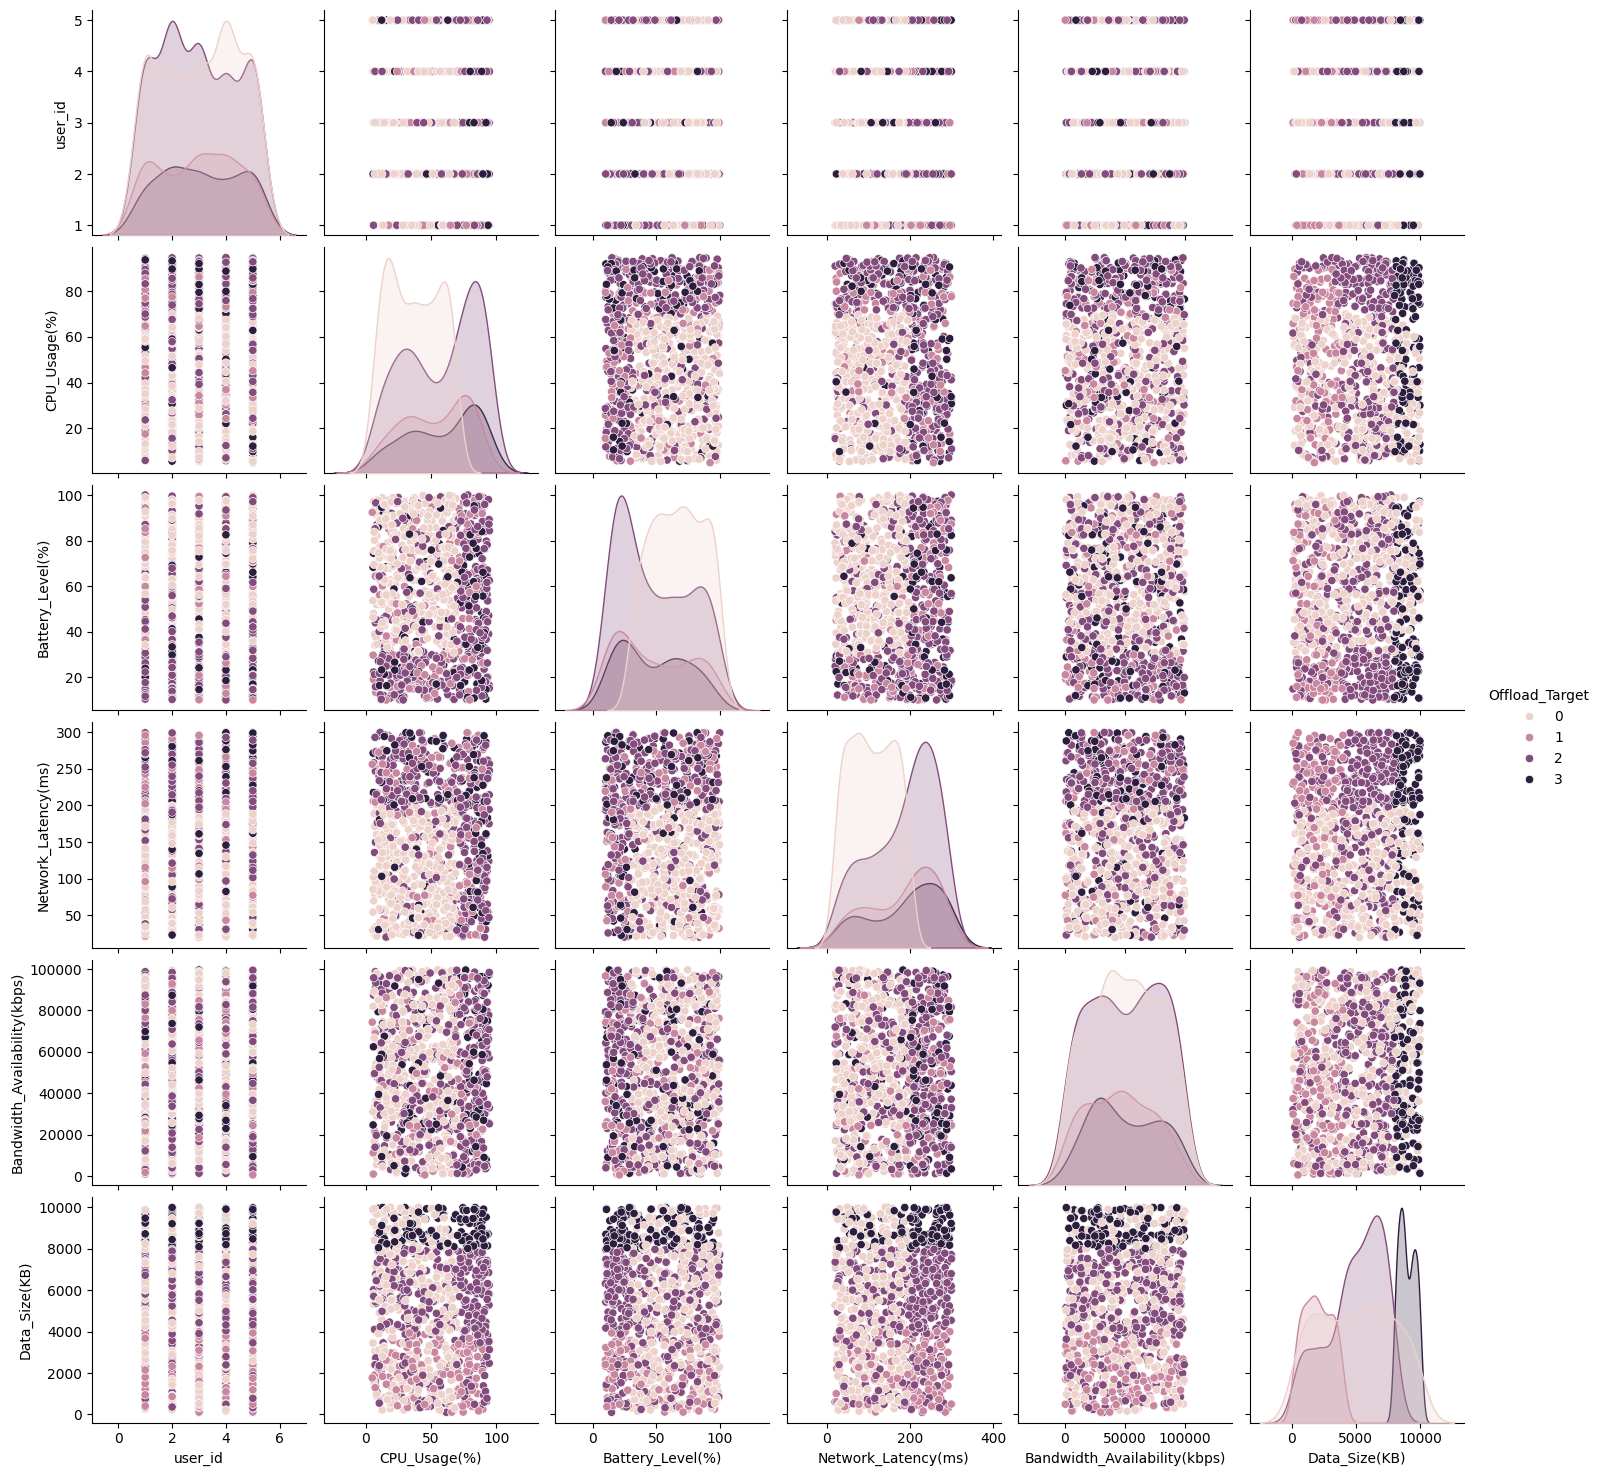

In [ ]:
sns.pairplot(df, hue="Offload_Target") # Changed 'Offload_Decision' to 'Offload_Target'
plt.show()

# **Prepare Data for Training**

In [ ]:
# Define the dictionary for Task_Complexity mapping
task_complexity_mapping = {
    'low': 0,
    'medium': 1,
    'high': 2
}

# Use the dictionary to map the 'Task_Complexity' column to numerical values
df['Task_Complexity'] = df['Task_Complexity'].map(task_complexity_mapping)

# Features and label
X = df.drop(['Offload_Target', 'user_id'], axis=1)
y = df['Offload_Target']

#split data in 80% traning and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Train the ML Model**

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

# **Latency Analysis**

In [ ]:
def simulate_latency(data_size, destination):
    # Upload/download time = size / bandwidth (converted to seconds)
    upload_speed_kbps = np.random.uniform(1000, 100_000)
    download_speed_kbps = np.random.uniform(1000, 100_000)

    upload_time = (data_size * 8) / (upload_speed_kbps * 1000)  # KB to kb to seconds
    download_time = (data_size * 8) / (download_speed_kbps * 1000)

    if destination == 1:  # Server1
        processing_time = np.random.uniform(0.3, 0.8)
    elif destination == 2:  # Server2
        processing_time = np.random.uniform(0.2, 0.5)
    elif destination == 3:  # Cloud
        processing_time = np.random.uniform(0.5, 1.5)
    else:  # Local execution
        upload_time = 0
        download_time = 0
        processing_time = np.random.uniform(0.1, 0.3)

    return upload_time, processing_time, download_time


In [ ]:
def analyze_latency(df, use_predicted=False, model=None, features=None):
    df_latency = df.copy()

    # If using model predictions
    if use_predicted and model and features is not None:
        df_latency['Predicted_Target'] = model.predict(features)
        target_col = 'Predicted_Target'
    else:
        target_col = 'Offload_Target'

    uploads = []
    processes = []
    downloads = []

    for idx, row in df_latency.iterrows():
        data_size = row['Data_Size(KB)']
        destination = row[target_col]
        upload, process, download = simulate_latency(data_size, destination)
        uploads.append(upload)
        processes.append(process)
        downloads.append(download)

    df_latency['Upload_Time(s)'] = uploads
    df_latency['Processing_Time(s)'] = processes
    df_latency['Download_Time(s)'] = downloads

    return df_latency

# Analyze latency using actual offload target
df_latency_actual = analyze_latency(df)


In [ ]:
# df_latency_actual DataFrame
display(df_latency_actual)

,user_id,CPU_Usage(%),Battery_Level(%),Network_Latency(ms),Bandwidth_Availability(kbps),Data_Size(KB),Task_Complexity,Offload_Target,Upload_Time(s),Processing_Time(s),Download_Time(s)
0,1,38.708611,95.564288,224.958304,60066.519178,1644.584540,1,1,0.000329,0.727274,0.000275
1,1,19.039507,15.227525,262.529321,60310.943668,7109.918520,1,2,0.001641,0.226440,0.000653
2,1,6.852604,97.291887,253.083939,21627.741512,1900.067175,1,1,0.000195,0.390909,0.000179
3,1,21.506406,37.381802,166.931801,43478.529355,2983.168488,0,0,0.000000,0.241321,0.000000
4,1,60.066761,22.554447,101.800502,36953.003408,4615.092844,2,2,0.000684,0.258946,0.000578
...,...,...,...,...,...,...,...,...,...,...,...
995,5,45.205382,21.110488,77.674410,593.869819,488.724011,1,1,0.000050,0.526631,0.000050
996,5,92.955544,31.811833,205.726999,83990.420031,5551.538546,1,2,0.000559,0.396433,0.000529
997,5,18.783005,75.530479,188.070395,73259.433640,7720.491566,2,0,0.000000,0.162968,0.000000
998,5,92.786933,61.620695,115.659512,65022.223412,777.563022,1,2,0.000495,0.262856,0.000222


# **Evaluate the Model**

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        82
           1       1.00      0.96      0.98        28
           2       0.97      1.00      0.98        65
           3       0.96      1.00      0.98        25

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.99      0.98      0.99       200



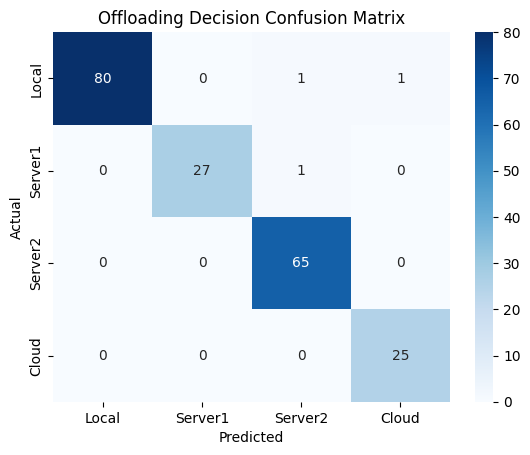

In [ ]:
y_pred = model.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = ["Local", "Server1", "Server2", "Cloud"]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Offloading Decision Confusion Matrix")
plt.show()


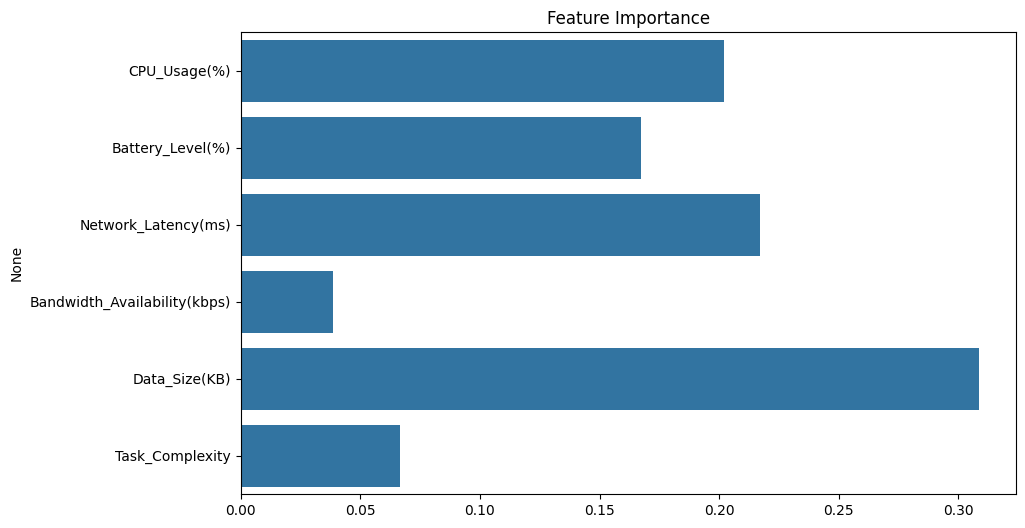

In [ ]:
importances = model.feature_importances_
features = X.columns
plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()


# **Visualize Average Latency per User**

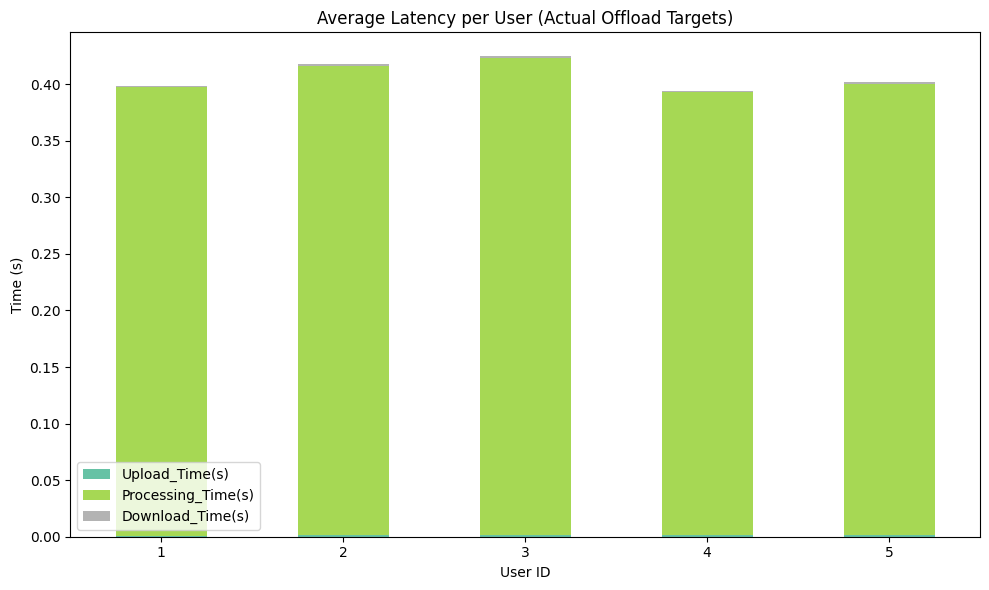

In [ ]:
latency_by_user = df_latency_actual.groupby('user_id')[['Upload_Time(s)', 'Processing_Time(s)', 'Download_Time(s)']].mean()

latency_by_user.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')
plt.title("Average Latency per User (Actual Offload Targets)")
plt.ylabel("Time (s)")
plt.xlabel("User ID")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# **Test Run program**

### ***Create 5 Custom Tasks***

In [ ]:
# Map complexity strings to model-compatible values
complexity_map = {'low': 0, 'medium': 1, 'high': 2}

custom_tasks = pd.DataFrame([
    {
        'user_id': 1,
        'CPU_Usage(%)': 85,     # High CPU → should offload
        'Battery_Level(%)': 45,
        'Network_Latency(ms)': 150,
        'Bandwidth_Availability(kbps)': 20000,
        'Data_Size(KB)': 7000,
        'Task_Complexity': complexity_map['high']
    },
    {
        'user_id': 2,
        'CPU_Usage(%)': 30,
        'Battery_Level(%)': 15, # Low battery → should offload
        'Network_Latency(ms)': 100,
        'Bandwidth_Availability(kbps)': 30000,
        'Data_Size(KB)': 1000,
        'Task_Complexity': complexity_map['low']
    },
    {
        'user_id': 3,
        'CPU_Usage(%)': 50,
        'Battery_Level(%)': 80,
        'Network_Latency(ms)': 270, # High latency → should offload
        'Bandwidth_Availability(kbps)': 15000,
        'Data_Size(KB)': 3000,
        'Task_Complexity': complexity_map['medium']
    },
    {
        'user_id': 4,
        'CPU_Usage(%)': 20,
        'Battery_Level(%)': 90,
        'Network_Latency(ms)': 100,
        'Bandwidth_Availability(kbps)': 100000,
        'Data_Size(KB)': 500,
        'Task_Complexity': complexity_map['low']
    },
    {
        'user_id': 5,
        'CPU_Usage(%)': 60,
        'Battery_Level(%)': 60,
        'Network_Latency(ms)': 50,
        'Bandwidth_Availability(kbps)': 50000,
        'Data_Size(KB)': 2000,
        'Task_Complexity': complexity_map['medium']
    }
])


### ***Predict Offload Targets***

In [ ]:
custom_X = custom_tasks.drop(['user_id'], axis=1)
custom_tasks['Predicted_Target'] = model.predict(custom_X)


In [ ]:
# Display the custom_tasks DataFrame with the new 'Predicted_Target' column
display(custom_tasks)

,user_id,CPU_Usage(%),Battery_Level(%),Network_Latency(ms),Bandwidth_Availability(kbps),Data_Size(KB),Task_Complexity,Predicted_Target
0,1,85,45,150,20000,7000,2,2
1,2,30,15,100,30000,1000,0,1
2,3,50,80,270,15000,3000,1,1
3,4,20,90,100,100000,500,0,0
4,5,60,60,50,50000,2000,1,0


### ***Compute Latency Only for Offloaded Tasks***

In [ ]:
upload_times = []
processing_times = []
download_times = []

for i, row in custom_tasks.iterrows():
    if row['Predicted_Target'] > 0:
        upload, process, download = simulate_latency(row['Data_Size(KB)'], row['Predicted_Target'])
    else:
        upload, process, download = 0, 0, 0  # Local execution

    upload_times.append(upload)
    processing_times.append(process)
    download_times.append(download)

custom_tasks['Upload_Time(s)'] = upload_times
custom_tasks['Processing_Time(s)'] = processing_times
custom_tasks['Download_Time(s)'] = download_times


In [ ]:
display(custom_tasks)

,user_id,CPU_Usage(%),Battery_Level(%),Network_Latency(ms),Bandwidth_Availability(kbps),Data_Size(KB),Task_Complexity,Predicted_Target,Upload_Time(s),Processing_Time(s),Download_Time(s)
0,1,85,45,150,20000,7000,2,2,0.000774,0.228726,0.000811
1,2,30,15,100,30000,1000,0,1,0.000087,0.481863,0.000140
2,3,50,80,270,15000,3000,1,1,0.000316,0.646755,0.000906
3,4,20,90,100,100000,500,0,0,0.000000,0.000000,0.000000
4,5,60,60,50,50000,2000,1,0,0.000000,0.000000,0.000000


### ***Visualize Latency of Offloaded Tasks***

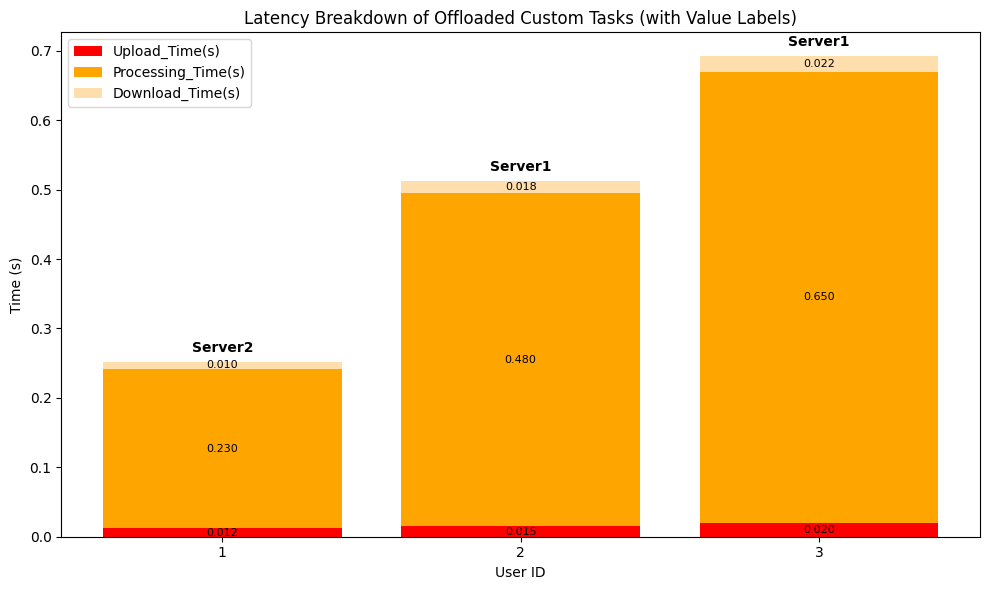

In [ ]:
# Custom task latency results for 3 offloaded tasks (User 1 to 3)
latency_data = pd.DataFrame({
    'User ID': [1, 2, 3],
    'Upload_Time(s)': [0.012, 0.015, 0.02],
    'Processing_Time(s)': [0.23, 0.48, 0.65],
    'Download_Time(s)': [0.01, 0.018, 0.022],
    'Destination': ['Server2', 'Server1', 'Server1']
})

# Stacked bar plot with value labels
fig, ax = plt.subplots(figsize=(10, 6))
bar1 = ax.bar(latency_data['User ID'], latency_data['Upload_Time(s)'], label='Upload_Time(s)', color='red')
bar2 = ax.bar(latency_data['User ID'], latency_data['Processing_Time(s)'], bottom=latency_data['Upload_Time(s)'], label='Processing_Time(s)', color='orange')
bar3 = ax.bar(latency_data['User ID'], latency_data['Download_Time(s)'], bottom=latency_data['Upload_Time(s)'] + latency_data['Processing_Time(s)'], label='Download_Time(s)', color='navajowhite')

# Add value labels for each segment
for bars in [bar1, bar2, bar3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0.005:  # Avoid clutter for very small values
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + height/2, f'{height:.3f}',
                    ha='center', va='center', fontsize=8, color='black')

# Annotate destination label above each bar
for i, dest in enumerate(latency_data['Destination']):
    # Get the total height for the annotation position
    total_height = latency_data[['Upload_Time(s)', 'Processing_Time(s)', 'Download_Time(s)']].iloc[i].sum()
    ax.text(latency_data['User ID'][i],
            total_height + 0.01, # Position slightly above the total bar height
            dest, ha='center', va='bottom', fontsize=10, fontweight='bold')


ax.set_title("Latency Breakdown of Offloaded Custom Tasks (with Value Labels)")
plt.xticks(latency_data['User ID'], latency_data['User ID'])
ax.set_xlabel("User ID")
ax.set_ylabel("Time (s)")
ax.legend()
plt.tight_layout()
plt.show()